ROC: {'mean': np.float64(-0.031615039629226835), 'ci_2.5': np.float64(-0.13127410791702798), 'ci_50': np.float64(-0.03149467922536192), 'ci_97.5': np.float64(0.06445603576751124)}
PR: {'mean': np.float64(-0.00362), 'ci_2.5': np.float64(-0.15272), 'ci_50': np.float64(-0.00356), 'ci_97.5': np.float64(0.13922)}


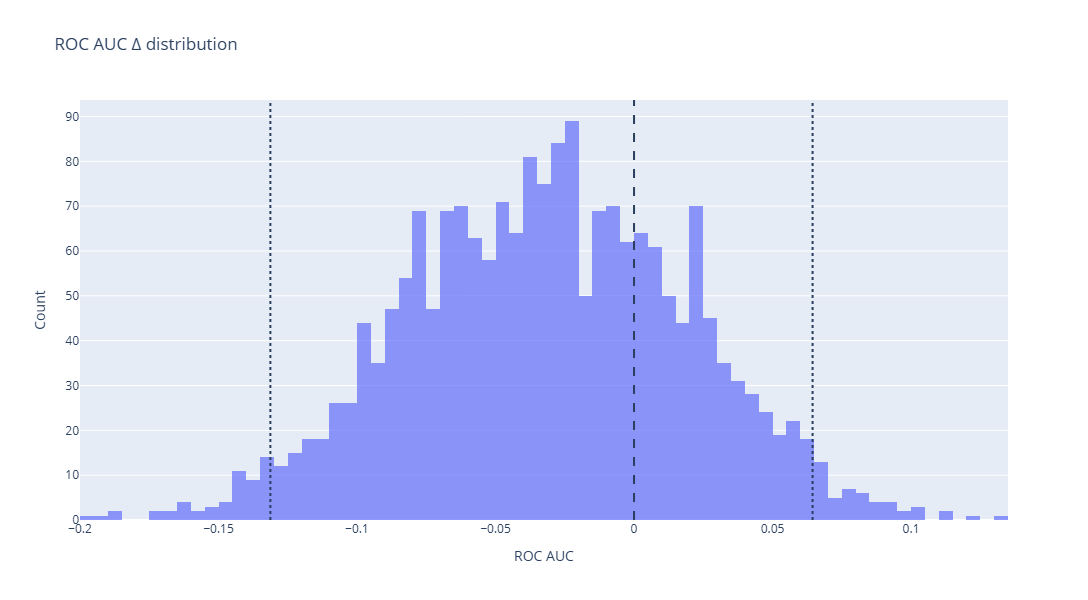

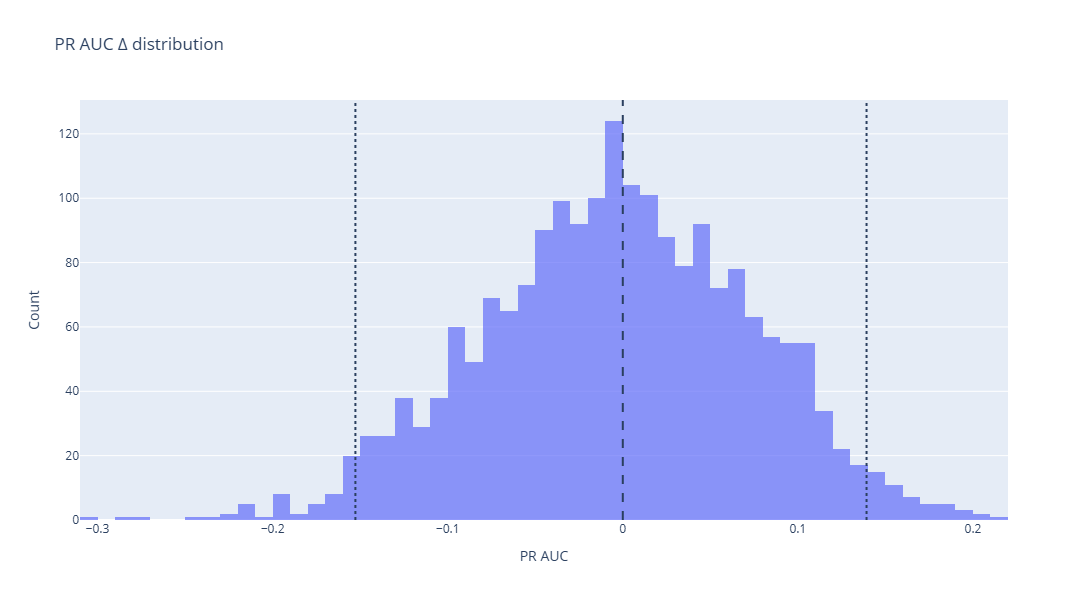

In [12]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

from sklearn.metrics import roc_auc_score, average_precision_score


def read_and_clean_excel(path, sheet_name="Лист1"):
    # читаем файл
    df = pd.read_excel(path, sheet_name=sheet_name)

    # оставляем только нужные колонки
    df = df[["target", "predict"]].copy()

    # приводим к строке и чистим
    for col in ["target", "predict"]:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.replace(",", ".", regex=False)
        )

        # переводим в числа
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # удаляем строки с NaN
    df = df.dropna(subset=["target", "predict"])

    # оставляем только валидный target (0/1)
    df = df[df["target"].isin([0, 1])]

    # финальные типы
    df["target"] = df["target"].astype(int)
    df["predict"] = df["predict"].astype(float)

    df = df.reset_index(drop=True)

    # print(f"{path}: осталось {len(df)} строк")
    return df


# =========================
# ЧТЕНИЕ 8 ФАЙЛОВ
# =========================

no_process_df_1 = read_and_clean_excel("no_process_1.xlsx")
no_process_df_2 = read_and_clean_excel("no_process_2.xlsx")
no_process_df_3 = read_and_clean_excel("no_process_3.xlsx")
no_process_df_4 = read_and_clean_excel("no_process_4.xlsx")

process_df_1 = read_and_clean_excel("process_1.xlsx")
process_df_2 = read_and_clean_excel("process_2.xlsx")
process_df_3 = read_and_clean_excel("process_3.xlsx")
process_df_4 = read_and_clean_excel("process_4.xlsx")


def mean_predictions(dfs):
    # проверка одинаковой длины
    lengths = [len(df) for df in dfs]
    if len(set(lengths)) != 1:
        raise ValueError(f"Разные длины датафреймов: {lengths}")

    # проверка одинакового target
    base_target = dfs[0]["target"].reset_index(drop=True)
    for i, df in enumerate(dfs[1:], start=2):
        cur_target = df["target"].reset_index(drop=True)
        if not base_target.equals(cur_target):
            raise ValueError(f"target не совпадает между dfs[0] и dfs[{i - 1}]")

    predict_mean = pd.concat(
        [df["predict"].reset_index(drop=True) for df in dfs],
        axis=1
    ).mean(axis=1)

    return pd.DataFrame({
        "target": base_target,
        "predict": predict_mean
    })


no_process_mean_df = mean_predictions([
    no_process_df_1,
    no_process_df_2,
    no_process_df_3,
    no_process_df_4,
])

process_mean_df = mean_predictions([
    process_df_1,
    process_df_2,
    process_df_3,
    process_df_4,
])


def bootstrap_roc_auc_delta(
    no_df,
    prep_df,
    n_bootstrap: int = 2000,
    seed: int = 42
):
    rng = np.random.default_rng(seed)

    y_true = no_df["target"].values
    p_raw = no_df["predict"].values
    p_prep = prep_df["predict"].values

    n = len(y_true)
    deltas = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        y_b = y_true[idx]
        raw_b = p_raw[idx]
        prep_b = p_prep[idx]

        if len(np.unique(y_b)) < 2:
            continue

        roc_raw = roc_auc_score(y_b, raw_b)
        roc_prep = roc_auc_score(y_b, prep_b)

        deltas.append(roc_prep - roc_raw)

    deltas = np.array(deltas)

    ci = np.percentile(deltas, [2.5, 50, 97.5])

    results = {
        "mean": deltas.mean(),
        "ci_2.5": ci[0],
        "ci_50": ci[1],
        "ci_97.5": ci[2],
    }

    return results, deltas


def bootstrap_pr_auc_delta(
    no_df,
    prep_df,
    n_bootstrap: int = 2000,
    seed: int = 42
):
    rng = np.random.default_rng(seed)

    y_true = no_df["target"].values
    p_raw = no_df["predict"].values
    p_prep = prep_df["predict"].values

    n = len(y_true)
    deltas = []

    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, n)

        y_b = y_true[idx]
        raw_b = p_raw[idx]
        prep_b = p_prep[idx]

        if len(np.unique(y_b)) < 2:
            continue

        pr_raw = average_precision_score(y_b, raw_b)
        pr_prep = average_precision_score(y_b, prep_b)

        deltas.append(pr_prep - pr_raw)

    deltas = np.array(deltas)

    ci = np.percentile(deltas, [2.5, 50, 97.5])

    results = {
        "mean": round(deltas.mean(), 5),
        "ci_2.5": round(ci[0], 5),
        "ci_50": round(ci[1], 5),
        "ci_97.5": round(ci[2], 5),
    }

    return results, deltas


"""
Критерий:
CI полностью > 0 → preprocessing улучшает
CI полностью < 0 → ухудшает
CI содержит 0 → статистически незначимо
"""


def plot_bootstrap_deltas(
    deltas,
    metric_name: str = "Metric Δ",
    nbins: int = 100,
    title: str | None = None,
    show_zero_line: bool = True,
    show_ci: bool = True
):
    deltas = np.asarray(deltas)

    fig = go.Figure()

    fig.add_trace(go.Histogram(
        x=deltas,
        nbinsx=nbins,
        name=metric_name,
        opacity=0.7
    ))

    if show_zero_line:
        fig.add_vline(x=0, line_dash="dash")

    if show_ci:
        ci_low, ci_high = np.percentile(deltas, [2.5, 97.5])
        fig.add_vline(x=ci_low, line_dash="dot")
        fig.add_vline(x=ci_high, line_dash="dot")

    fig.update_layout(
        title=title or f"{metric_name} Δ distribution",
        width=800,
        height=600,
        showlegend=False,
        xaxis_title=metric_name,
        yaxis_title="Count"
    )

    fig.show()


roc_res, roc_deltas = bootstrap_roc_auc_delta(no_process_mean_df, process_mean_df)
pr_res, pr_deltas = bootstrap_pr_auc_delta(no_process_mean_df, process_mean_df)

print("ROC:", roc_res)
print("PR:", pr_res)

plot_bootstrap_deltas(
    roc_deltas,
    metric_name="ROC AUC"
)

plot_bootstrap_deltas(
    pr_deltas,
    metric_name="PR AUC"
)